In [ ]:
# استدعاء المكتبات الأساسية
import pandas as pd
import numpy as np

# تقسيم البيانات
from sklearn.model_selection import train_test_split

# النموذج المحسّن
from sklearn.ensemble import RandomForestRegressor

# مقاييس التقييم
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/shboulsara47-dotcom/Sara_House-Price-Prediction/refs/heads/main/kc_house_data_after.csv")

In [ ]:
df.dtypes

,0
price,float64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64
grade,int64


In [ ]:
# فحص القيم المفقودة قبل أي معالجة
print("فحص القيم المفقودة في كل عمود:")
missing_values = df.isnull().sum()
print(missing_values)

# حساب مجموع القيم المفقودة
total_missing = missing_values.sum()
print("\nإجمالي القيم المفقودة:", total_missing)

# اتخاذ القرار بناءً على النتيجة
if total_missing == 0:
    print("\nلا توجد قيم مفقودة في البيانات لذلك لم يتم حذف أو تعويض أي بيانات حفاظاً على حجم البيانات")
else:
    print("\nيوجد قيم مفقودة سيتم تعويضها باستخدام الوسيط للأعمدة الرقمية")
    df.fillna(df.median(), inplace=True)

    print("\nتم التعويض إعادة الفحص:")
    print(df.isnull().sum())

فحص القيم المفقودة في كل عمود:
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

إجمالي القيم المفقودة: 0

لا توجد قيم مفقودة في البيانات لذلك لم يتم حذف أو تعويض أي بيانات حفاظاً على حجم البيانات


In [ ]:
# حذف الاعمدة غير المهمة للتنبؤ بالسعر
# عمود id مجرد رقم تعريفي
# عمود date لا يفيد في التنبؤ في هذا النموذج
df = df.drop(["id", "date"], axis=1, errors="ignore")

# انشاء ميزة جديدة
# حساب نسبة مساحة المنزل الى مساحة الارض
# هذا يساعد النموذج يفهم العلاقة بين البناء ومساحة الارض
df["living_ratio"] = df["sqft_living"] / df["sqft_lot"]


In [ ]:
# فحص توزيع السعر لمعرفة اذا كان في انحراف
df["price"].describe()

,price
count,2.140800e+04
mean,5.189366e+05
std,2.866135e+05
min,7.500000e+04
25%,3.200000e+05
50%,4.500000e+05
75%,6.350000e+05
max,1.999950e+06


In [ ]:

# عرض أول 5 صفوف
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,living_ratio
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0.208850
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0.354874
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0.077000
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0.392000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0.207921


In [ ]:
# حذف القيم المفقودة إن وجدت
df = df.dropna()

# التأكد من عدم وجود قيم مفقودة
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


In [ ]:
# استخدام جميع الميزات ما عدا السعر
X = df.drop("price", axis=1)

# الهدف هو السعر
y = df["price"]

<Axes: >

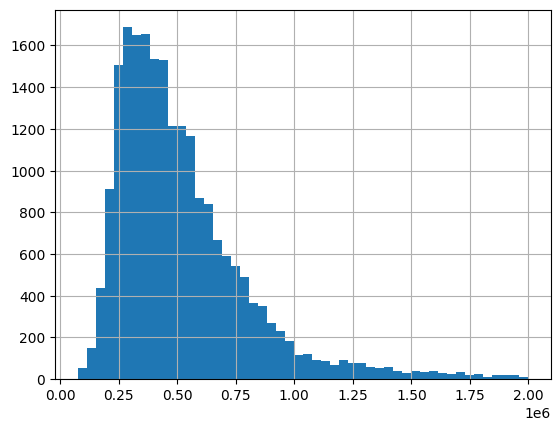

In [ ]:
df["price"].hist(bins=50)

تبين أن توزيع السعر كان منحرف إلى اليمين لذلك تم تطبيق Log Transformation لتقليل الانحراف وجعل التوزيع أقرب الى الطبيعي مما يساعد النموذج على التعلم بشكل أفضل وتحسين دقة التنبؤ.

In [ ]:
import numpy as np

df["price"] = np.log1p(df["price"])

<Axes: >

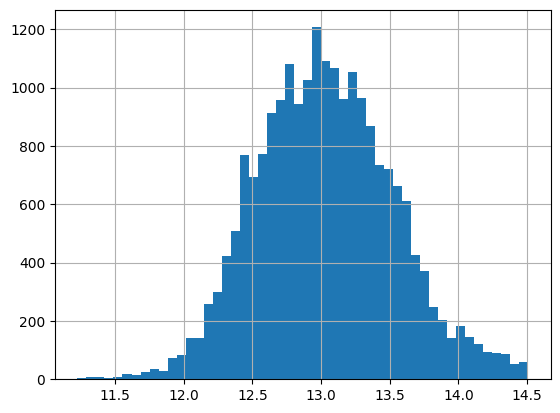

In [ ]:
df["price"].hist(bins=50)

In [ ]:
# تقسيم أول 70 تدريب و 30 مؤقت
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# تقسيم 30 إلى 15 تحقق و 15 اختبار
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

print("Training size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Training size: 14985
Validation size: 3211
Test size: 3212


In [ ]:
# ملاحظة :
# لم يتم تطبيق Scaling لأن نموذج Random Forest
# لا يعتمد على المسافات أو حساب الانحدار الخطي
# بل يعتمد على تقسيم الأشجار
# لذلك لا يتأثر باختلاف مقياس المتغيرات

In [ ]:
# إنشاء نموذج Random Forest محسّن
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

# تدريب النموذج على بيانات التدريب فقط
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=200, random_state=42)

In [ ]:
# التنبؤ على بيانات التحقق
rf_val_pred = rf_model.predict(X_val)

rf_val_r2 = r2_score(y_val, rf_val_pred)
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)

print("Validation R2:", rf_val_r2)
print("Validation MAE:", rf_val_mae)

Validation R2: 0.8794581836061457
Validation MAE: 63127.033380779496


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# التنبؤ على بيانات الاختبار
rf_test_pred = rf_model.predict(X_test)

# حساب المقاييس
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_test_mae = mean_absolute_error(y_test, rf_test_pred)
rf_test_mse = mean_squared_error(y_test, rf_test_pred)
rf_test_rmse = rf_test_mse ** 0.5

# طباعة النتائج
print("Final Test R2:", rf_test_r2)
print("Final Test MAE:", rf_test_mae)
print("Final Test RMSE:", rf_test_rmse)

Final Test R2: 0.8717710738520865
Final Test MAE: 63671.14113504975
Final Test RMSE: 104420.85687895458


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ---------------------------------------------------
# Baseline Model
# نموذج بسيط يتنبأ بمتوسط السعر فقط
# الهدف منه يكون مرجع للمقارنة مع النماذج الأخرى
# ---------------------------------------------------

baseline_model = DummyRegressor(strategy="mean")

# تدريب على بيانات التدريب فقط
baseline_model.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_base_pred = baseline_model.predict(X_test)

# حساب المقاييس على test set
baseline_r2 = r2_score(y_test, y_base_pred)
baseline_mae = mean_absolute_error(y_test, y_base_pred)

print("Baseline R2:", baseline_r2)
print("Baseline MAE:", baseline_mae)

Baseline R2: -0.00011803199900350947
Baseline MAE: 212207.9348437686


In [ ]:
# ---------------------------------------------------
# مقارنة أداء النموذج الأساسي والنموذج المحسن
# تمت المقارنة باستخدام نفس بيانات الاختبار (Test Set)
# لضمان عدالة التقييم
# ---------------------------------------------------

print("----- Baseline Model -----")
print("R2:", baseline_r2)
print("MAE:", baseline_mae)

print("\n----- Improved Model (Random Forest) -----")
print("R2:", rf_test_r2)
print("MAE:", rf_test_mae)

----- Baseline Model -----
R2: -0.00011803199900350947
MAE: 212207.9348437686

----- Improved Model (Random Forest) -----
R2: 0.8717710738520865
MAE: 63671.14113504975
